# UID versus card1

`card1` is the card token. The UID splits that token by billing region and the day the card was first seen:

`D1n = floor(TransactionDT / 86400) - D1`

`uid = card1 + addr1 + D1n`

`D1n` stays fixed for one card. `D1` itself grows every day, so it is not part of the id.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

IEEE_DIR = REPO_ROOT / "data/raw/ieee-fraud-detection"
tx = pd.read_csv(
    IEEE_DIR / "train_transaction.csv",
    usecols=["card1", "addr1", "D1", "TransactionDT", "TransactionAmt"],
)
tx.shape

(590540, 5)

In [2]:
day = np.floor(tx["TransactionDT"] / (24 * 60 * 60))
tx["D1n"] = day - tx["D1"]
tx["uid"] = (
    tx["card1"].astype(str)
    + "_"
    + tx["addr1"].astype(str)
    + "_"
    + tx["D1n"].astype(str)
)

card = tx.groupby("card1", dropna=False)["TransactionAmt"].agg(txn_count="size", avg_amount="mean")
uid = tx.groupby("uid", dropna=False)["TransactionAmt"].agg(txn_count="size", avg_amount="mean")

summary = pd.DataFrame(
    {
        "card1": [
            tx["card1"].nunique(dropna=False),
            card["txn_count"].mean(),
            card["avg_amount"].mean(),
        ],
        "uid": [
            tx["uid"].nunique(dropna=False),
            uid["txn_count"].mean(),
            uid["avg_amount"].mean(),
        ],
    },
    index=["n groups", "mean transactions per group", "mean of group average amount"],
)
summary.round(2)

,card1,uid
n groups,13553.00,199071.00
mean transactions per group,43.57,2.97
mean of group average amount,149.57,161.19


In [3]:
uids_per_card = tx.groupby("card1")["uid"].nunique()
print("uids inside one card1")
print(uids_per_card.describe(percentiles=[0.5, 0.9, 0.99]).round(1))
print("share of card1 values that split into more than one uid:", round(float((uids_per_card > 1).mean()), 3))

uids inside one card1
count    13553.0
mean        14.7
std         90.7
min          0.0
50%          2.0
90%         17.0
99%        252.0
max       3741.0
Name: uid, dtype: float64
share of card1 values that split into more than one uid: 0.573


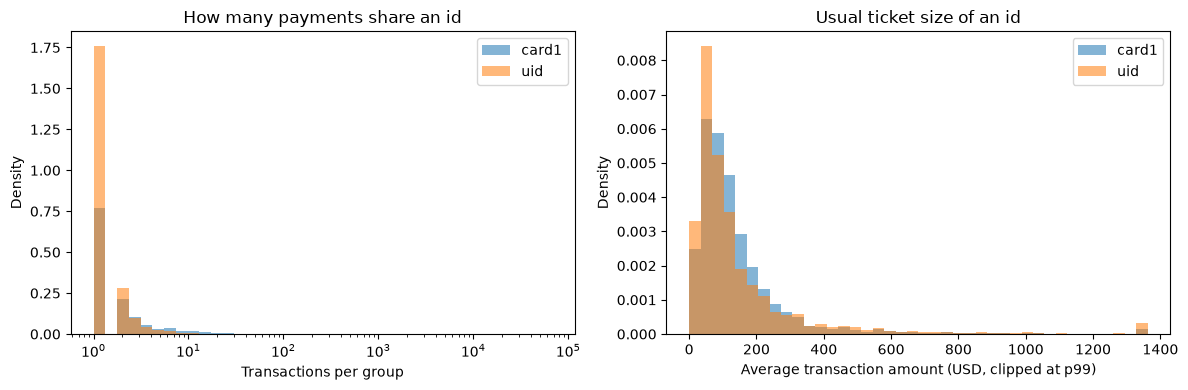

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins_count = np.logspace(0, np.log10(max(card["txn_count"].max(), uid["txn_count"].max())), 40)
axes[0].hist(card["txn_count"], bins=bins_count, density=True, alpha=0.55, label="card1", color="#1f77b4")
axes[0].hist(uid["txn_count"], bins=bins_count, density=True, alpha=0.55, label="uid", color="#ff7f0e")
axes[0].set_xscale("log")
axes[0].set_xlabel("Transactions per group")
axes[0].set_ylabel("Density")
axes[0].set_title("How many payments share an id")
axes[0].legend()

amount_cap = np.quantile(np.concatenate([card["avg_amount"], uid["avg_amount"]]), 0.99)
axes[1].hist(card["avg_amount"].clip(upper=amount_cap), bins=40, density=True, alpha=0.55, label="card1", color="#1f77b4")
axes[1].hist(uid["avg_amount"].clip(upper=amount_cap), bins=40, density=True, alpha=0.55, label="uid", color="#ff7f0e")
axes[1].set_xlabel("Average transaction amount (USD, clipped at p99)")
axes[1].set_ylabel("Density")
axes[1].set_title("Usual ticket size of an id")
axes[1].legend()

fig.tight_layout()
plt.show()